In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# 10을 이진법으로 나타내면
a=str(bin(10))
print(a) # 1010
temp=[0]*(9-len(a)+2) # len(a) = 6
print(temp)
temp=temp+[int(a[2])] # a[2] = 1
print(temp)
temp=temp+[int(a[3])] # a[3] = 0
temp=temp+[int(a[4])] # a[4] = 1
temp=temp+[int(a[5])] # a[5] = 0
print(temp)

0b1010
[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 1, 0]


In [14]:
# Data synthesis
x = []
for i in range(512):
    a = str(bin(i))
    temp = [0]*(9-len(a)+2)  # e.g., bin(2) --> 0b10 --> [0 0 0 0 0 0 0 1 0]
    for j in range(2,len(a)):
        temp = temp + [int(a[j])]
    x.append(temp)    
x = np.array(x)
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [1, 1, 1, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 1, 0],
       [1, 1, 1, ..., 1, 1, 1]])

In [15]:
z_true = np.zeros(512)
for i in range(len(z_true)):
    #0,4 or 1,5 or 3,7 or 4,8이면 Ztrue=1
    if (x[i,0] and x[i,4]) or (x[i,1] and x[i,5]) or (x[i,3] and x[i,7]) or (x[i,4] and x[i,8]): 
        z_true[i] = 1.

x = x.astype(float)
index_0 = np.where(z_true == 0.) # 0~511까지 누가 0인지
index_1 = np.where(z_true == 1.) # 0~511까지 누가 1인지
print(index_0[0])
print(index_1[0])

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  18
  20  22  24  26  28  30  32  33  36  37  40  41  44  45  48  52  56  60
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  82
  84  86  88  90  92  94  96  97 100 101 104 105 108 109 112 116 120 124
 128 129 130 131 132 133 134 135 144 146 148 150 160 161 164 165 176 180
 192 193 194 195 196 197 198 199 208 210 212 214 224 225 228 229 240 244
 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 288 289
 292 293 296 297 300 301 320 321 322 323 324 325 326 327 328 329 330 331
 332 333 334 335 352 353 356 357 360 361 364 365 384 385 386 387 388 389
 390 391 416 417 420 421 448 449 450 451 452 453 454 455 480 481 484 485]
[ 17  19  21  23  25  27  29  31  34  35  38  39  42  43  46  47  49  50
  51  53  54  55  57  58  59  61  62  63  81  83  85  87  89  91  93  95
  98  99 102 103 106 107 110 111 113 114 115 117 118 119 121 122 123 125
 126 127 136 137 138 139 140 141 142 143 145 147 1

Images (z = 0)


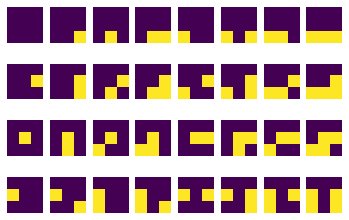

In [16]:
# Check images with z_true
print('Images (z = 0)')
figure = plt.figure()
sample_num = 32
for index in range(sample_num):
    plt.subplot(4, 8, index+1)
    plt.axis('off') # 축 없애기
    plt.imshow(x[index_0[0][index]].reshape(3,3)) #, cmap='gray_r')  # z=0인 애들의 인덱스, 그것을 3x3로 reshape

Images (z = 1)


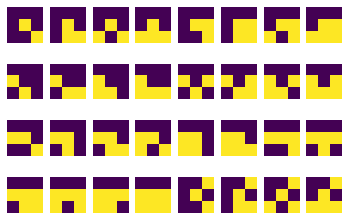

In [17]:
print('Images (z = 1)')
figure = plt.figure()
sample_num = 32
for index in range(sample_num):
    plt.subplot(4, 8, index+1)
    plt.axis('off')
    plt.imshow(x[index_1[0][index]].reshape(3,3)) #, cmap='gray_r')

In [18]:
# 시그모이드 함수 정의
def sigmoid(s):
    return 1./(1.+np.exp(-s))

# forward
def forward(x, W, a, v, b):
    s = np.zeros([x.shape[0], 4]) # x.shape[0] = batch_size
    s[:,0] = x[:,0]*W[0,0] + x[:,1]*W[0,1] + x[:,3]*W[1,0] + x[:,4]*W[1,1] + a # (10,)*상수 = 상수
    s[:,1] = x[:,1]*W[0,0] + x[:,2]*W[0,1] + x[:,4]*W[1,0] + x[:,5]*W[1,1] + a
    s[:,2] = x[:,3]*W[0,0] + x[:,4]*W[0,1] + x[:,6]*W[1,0] + x[:,7]*W[1,1] + a
    s[:,3] = x[:,4]*W[0,0] + x[:,5]*W[0,1] + x[:,7]*W[1,0] + x[:,8]*W[1,1] + a
    y = sigmoid(s) # (10,4)
    z = sigmoid(np.dot(y,v) + b) # (10,4)*(4,) = (10,)
    return y, z

In [19]:
# backward
def backward(x, z_true, W, a, v, b): # z_true: 정답, 나머자: 파라미터
    y, z = forward(x, W, a, v, b)
    """
    s1 = x*W+a
    y = sigmoid(s1)
    s2 = y*v+b
    z = sigmoid(s2)
    
    dLdv = dLdz * dzds2 * ds2dv =  -(z_true-z) *  z(1-z) * y = error_z * y 
    dLdb = dLdy * dyds2 * ds2db =  -(z_true-z) *  z(1-z) * 1 = error_z * 1
    dLdW = dLdy * dyds2 * ds2dy * dyds1 * ds1dW = -(z_true-z) *  z(1-z) * v * y(1-y) * x = error_y * x
    dLda = dLdy * dyds2 * ds2dy * dyds1 * ds1da = -(z_true-z) *  z(1-z) * v * y(1-y) * (-1) = error_y * 1
    
    error_z = -(z_true-z) *  z(1-z)
    error_y = error_z * v * y(1-y) 
    """
    error_z = (z - z_true)*z*(1.-z) # (10,) * (10,) * (10,) = (10,)
    # 에러가 v라는 weight로 redistributed되는 과정, np.newaxis: 열이 하나인 텐서로 바꾼 것
    error_y = error_z[:,np.newaxis] * v[np.newaxis,:] * y*(1.-y) # (10,1) * (1,4) * (10,4)*(10,4) = (10,4)
    db = np.sum(error_z, axis=0) # (10,)을 열방향으로 합치면 하나의 상수
    dv = np.matmul(error_z.T, y) # (10,) * (10,4) = (4,)
    da = np.sum(error_y[:,0], axis=0) + np.sum(error_y[:,1], axis=0) + np.sum(error_y[:,2], axis=0) + np.sum(error_y[:,3], axis=0) # 하나의 상수
    dW = np.zeros([2,2])
    # (10,), (10,)을 내적하면 하나의 상수
    dW[0,0] = np.dot(error_y[:,0], x[:,0]) + np.dot(error_y[:,1], x[:,1]) + np.dot(error_y[:,2], x[:,3]) + np.dot(error_y[:,3], x[:,4])
    dW[0,1] = np.dot(error_y[:,0], x[:,1]) + np.dot(error_y[:,1], x[:,2]) + np.dot(error_y[:,2], x[:,4]) + np.dot(error_y[:,3], x[:,5])
    dW[1,0] = np.dot(error_y[:,0], x[:,3]) + np.dot(error_y[:,1], x[:,4]) + np.dot(error_y[:,2], x[:,6]) + np.dot(error_y[:,3], x[:,7])
    dW[1,1] = np.dot(error_y[:,0], x[:,4]) + np.dot(error_y[:,1], x[:,5]) + np.dot(error_y[:,2], x[:,7]) + np.dot(error_y[:,3], x[:,8])
    return np.dot(z-z_true, z-z_true)/2, db, dv, da, dW # 에러와 기울기값 반환    

In [20]:
# learning rate
alpha = 0.1 
# 파라미터 초기값
W = np.random.normal(0., 0.1, [2,2]) # 평균이 0, 표편이 0.1인 정규분포에서 2x2개를 뽑음
a = np.random.normal(0., 0.1) # 1개만
v = np.random.normal(0., 0.1, 4)
b = np.random.normal(0., 0.1)

# train
batch_size = 10 # 512 중에 10개 뽑기 (크다고 좋은 건 아님)
for epoch in range(10000): # 한 batch를 epoch라고 간주
    batch = np.random.randint(0, 512, batch_size) # 0에서 512 사이에서 임의의 정수를 batch_size개 만큼 뽑기
    x_batch = x[batch, :] # :는 각 샘플에 해당하는 3x3 픽셀 모두를 가져온다는 의미
    z_batch = z_true[batch]
    cost, db, dv, da, dW = backward(x_batch, z_batch, W, a, v, b)
    
    # 업데이트
    b = b - alpha*db
    v = v - alpha*dv
    a = a - alpha*da
    W = W - alpha*dW
   
    # 천 번에 한 번씩 확인
    if epoch % 1000 == 0:
        print('Epoch: {:>4}, Cost: {:>.5}'.format(epoch, cost))

Epoch:    0, Cost: 1.2204
Epoch: 1000, Cost: 0.87002
Epoch: 2000, Cost: 0.10128
Epoch: 3000, Cost: 0.024754
Epoch: 4000, Cost: 0.035779
Epoch: 5000, Cost: 0.023658
Epoch: 6000, Cost: 0.020602
Epoch: 7000, Cost: 0.013117
Epoch: 8000, Cost: 0.0095628
Epoch: 9000, Cost: 0.0060639


W: [[ 5.76961421 -0.10974954]
 [-0.10198431  5.74571686]]


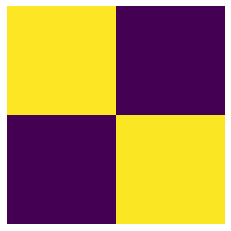

a: -8.663576003095237
v: [6.72563588 7.23886059 7.2449512  6.74922754]
b: -4.055630209281174


In [21]:
# 결과 확인
print('W:',W)
plt.axis('off')
plt.imshow(W) #, cmap='gray_r')
plt.show()
print('a:',a)
print('v:',v) # 동등해야 좋은 것
print('b:',b)

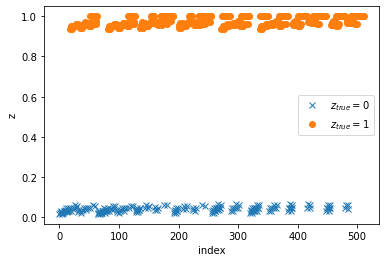

In [22]:
# Validate the inference of z
y, z = forward(x, W, a, v, b)

# print(z[index_0])  
# print(z[index_1])
plt.plot(index_0[0], z[index_0],'x', label = '$z_{true} = 0$')
plt.plot(index_1[0], z[index_1],'o', label = '$z_{true} = 1$')
plt.xlabel('index')
plt.ylabel('z')
plt.legend()
plt.show() # 한 치의 오차도 없이 모두 잘 분류함